<a href="https://colab.research.google.com/github/Jahnavi-Punnam/NASSCOM-Lab/blob/main/WEEK-3/U6_Probability_Statistics_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [ ]:
# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [ ]:
# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [ ]:
flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)                             # number of heads: 0, 1, or 2

# 1. P(both heads) -> heads == 2
p_both_heads = (heads == 2).mean()
print('P(both heads)   ~', round(p_both_heads, 3), '(true 0.25)')

# 2. P(at least one head) -> heads >= 1
p_at_least_one = (heads >= 1).mean()
print('P(at least one)  ~', round(p_at_least_one, 3), '(true 0.75)')

# 3. P(0) + P(1) + P(2) should sum to 1
p_0 = (heads == 0).mean()
p_1 = (heads == 1).mean()
p_2 = (heads == 2).mean()

print('P(0) + P(1) + P(2) =', round(p_0 + p_1 + p_2, 3))

P(both heads)   ~ 0.252 (true 0.25)
P(at least one)  ~ 0.749 (true 0.75)
P(0) + P(1) + P(2) = 1.0


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [ ]:
# LAB EXERCISE 2 — Conditional probability

rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)
# First condition on rolls < 4, then check which are odd
less_than_4 = rolls[rolls < 4]
p_odd_given_less4 = (less_than_4 % 2 == 1).mean()

print('P(odd | <4) =', round(p_odd_given_less4, 3),
      '(true 2/3)')

# 2. P(roll < 4) overall
p_less4 = (rolls < 4).mean()

print('P(roll < 4) =', round(p_less4, 3),
      '(true 0.5)')

# 3. Compare P(odd | <4) with P(odd) overall
p_odd = (rolls % 2 == 1).mean()

print('P(odd)      =', round(p_odd, 3),
      '(true 0.5)')

print('Independent?',
      np.isclose(p_odd_given_less4, p_odd, atol=0.02))

P(odd | <4) = 0.668 (true 2/3)
P(roll < 4) = 0.499 (true 0.5)
P(odd)      = 0.503 (true 0.5)
Independent? False


In [ ]:
# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
 #-----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


In [ ]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05

# 2. P('free') via total probability
p_free = (
    p_free_given_spam * p_spam
    + p_free_given_ham * (1 - p_spam)
)

print('P("free") =', round(p_free, 3))

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (
    p_free_given_spam * p_spam
    / p_free
)

print('P(spam | "free") =', round(p_spam_given_free, 3))

P("free") = 0.16
P(spam | "free") = 0.75


In [ ]:

# -----------------------------------------------------------
# 🔹 4A. BERNOULLI & POISSON (discrete)
# -----------------------------------------------------------

# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


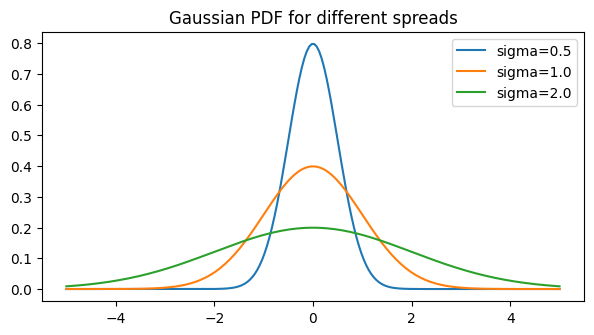

In [ ]:

# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Sample mean = 2.006
True mean   = 2


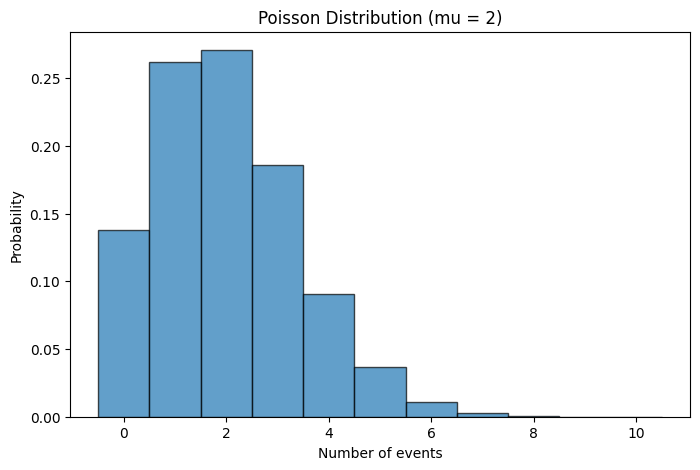

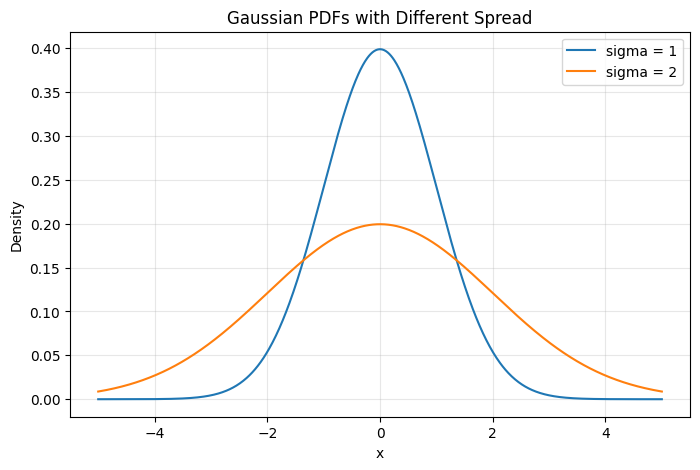

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Poisson(mu=2) samples + mean
samples = np.random.poisson(lam=2, size=10_000)

sample_mean = samples.mean()

print('Sample mean =', round(sample_mean, 3))
print('True mean   =', 2)


# 2. Histogram of the samples
plt.figure(figsize=(8, 5))

plt.hist(
    samples,
    bins=np.arange(-0.5, samples.max() + 1.5, 1),
    density=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('Number of events')
plt.ylabel('Probability')
plt.title('Poisson Distribution (mu = 2)')
plt.show()


# 3. Gaussian PDF for two different sigmas
x = np.linspace(-5, 5, 1000)

mu = 0
sigma1 = 1
sigma2 = 2

pdf1 = norm.pdf(x, loc=mu, scale=sigma1)
pdf2 = norm.pdf(x, loc=mu, scale=sigma2)

plt.figure(figsize=(8, 5))

plt.plot(x, pdf1, label='sigma = 1')
plt.plot(x, pdf2, label='sigma = 2')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Gaussian PDFs with Different Spread')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
